**Copyright (c) 2023** Andrea Calabrese, Stefano Quer, and Giovanni Squillero.  
Distributed under a BSD 3-Clause license (see `LICENSE.md`)

In [1]:
import logging

import pickle
import json
from random import seed

from enum import Enum
from dataclasses import dataclass
from collections import defaultdict

from glob import glob
from os import path

In [2]:
from tqdm.auto import tqdm

from scipy import stats
import pandas as pd
import seaborn as sns

import names

In [3]:
class Side(Enum):
    TOP = 1
    BOTTOM = -1


@dataclass(frozen=True, slots=True)
class Point:
    side: Side
    x: float
    y: float


@dataclass(kw_only=True, slots=True)
class Board:
    name: str
    size: tuple[float, float]
    num_points: int
    num_nets: int
    test_points: dict
    nets: dict

### I/O

In [4]:
def parse_name(name):
    r"""Converts a name like FOO_BAR_42_X to a tuple for ordering."""
    data = list()
    for e in name.split('_'):
        try:
            e = int(e)
        except ValueError:
            pass
        data.append(e)
    return tuple(data)

In [5]:
def read_stq(filename: str, name=None) -> Board:
    r"""Reads a board in Stefano's own text format"""
    test_points = dict()
    nets = dict()
    try:
        with open(filename) as board_file:
            for line in board_file:
                tag, *tokens = line.split()
                if tag == '.point':
                    test_points[tokens[0]] = Point(
                        side=Side.TOP if tokens[1] == 'T' else Side.BOTTOM,
                        x=float(tokens[2]),
                        y=float(tokens[3]),
                    )
                elif tag == '.net':
                    nets[tokens[0]] = set(tokens[2:])
                elif tag == '.width':
                    width = int(tokens[0])
                elif tag == '.height':
                    height = int(tokens[0])
    except OSError as problem:
        logging.error("read_stq: %s", problem)
        return None
    if not name:
        name = f'Unknown-{len(test_points)}-{len(nets)}'
    return Board(
        name=name,
        size=(width, height),
        num_points=len(test_points),
        num_nets=len(nets),
        test_points=test_points,
        nets=nets,
    )

In [6]:
def read_spea(filename: str, name=None) -> Board:
    r"""Reads a board in legacy SPEAS's CSV format."""
    test_points = dict()
    nets = defaultdict(set)
    try:
        df = pd.read_csv(filename, sep=';', decimal=',')
        for _, row in df.iterrows():
            test_points[row['TP_NAME']] = Point(
                side=Side.TOP if row['ACCESS_SID'] == 'T' else Side.BOTTOM,
                x=row['X_POSITION'],
                y=row['Y_POSITION'],
            )
            nets[row['NET_NAME']].add(row['TP_NAME'])
    except OSError as problem:
        logging.error("read_spea: %s", problem)
        return None
    if not name:
        name = f'Unknown-{len(test_points)}-{len(nets)}'
    return Board(
        name=name,
        size=(-1, -1),
        num_points=len(test_points),
        num_nets=len(nets),
        test_points=test_points,
        nets=nets,
    )

In [7]:
def read_json(filename: str, name=None) -> Board:
    r"""Reads a board in Giovanni's verbose, yet portable JSON format."""
    with open(filename) as json_in:
        jraw = json.load(json_in)
    return Board(
        name=jraw['name'],
        size=(jraw['size']['width'], jraw['size']['height']),
        num_points=jraw['size']['test_points'],
        num_nets=jraw['size']['nets'],
        test_points={n: Point(Side.TOP, p[0], p[1]) for n, p in jraw['test_points']['top'].items()}
        | {n: Point(Side.BOTTOM, p[0], p[1]) for n, p in jraw['test_points']['bottom'].items()},
        nets=jraw['nets'],
    )


def write_json(board: Board, filename: str) -> None:
    r"""Writes a board into Giovanni's verbose, yet portable JSON format."""

    json_data = dict()
    json_data['name'] = board.name
    json_data['size'] = dict()
    json_data['size']['width'] = board.size[0]
    json_data['size']['height'] = board.size[1]
    json_data['size']['test_points'] = board.num_points
    json_data['size']['nets'] = board.num_nets
    json_data['test_points'] = dict()
    json_data['test_points']['top'] = {
        n: (p.x, p.y)
        for n, p in sorted(board.test_points.items(), key=lambda x: parse_name(x[0]))
        if p.side == Side.TOP
    }
    json_data['test_points']['bottom'] = {
        n: (p.x, p.y)
        for n, p in sorted(board.test_points.items(), key=lambda x: parse_name(x[0]))
        if p.side == Side.BOTTOM
    }
    json_data['nets'] = {
        n: sorted(p) for n, p in sorted(board.nets.items(), key=lambda d: len(d[1]), reverse=True)
    }
    try:
        with open(filename, 'w') as board_file:
            json.dump(json_data, board_file, indent='\t')
    except OSError as problem:
        logging.error("write_json: %s", problem)

#### Convert to GX-JSON

In [8]:
CONVERT_TO_GXJSON = False
if CONVERT_TO_GXJSON:
    ALL_NAMES = list()
    for fullpath in tqdm(glob('boards-spea/*/TPLIST.csv')):
        _, name = path.split(path.dirname(fullpath))
        board = read_spea(fullpath, name=name)
        write_json(board, f'{path.dirname(fullpath)}/{board.name}.json')
        ALL_NAMES.append(board.name)

    for fullpath in tqdm(glob('boards-stq/*/board.txt')):
        _, name = path.split(path.dirname(fullpath))
        board = read_stq(fullpath)
        code = board.num_nets * 31 + board.num_points
        seed(code)
        board.name = f'''{names.get_first_name(gender='female')}-{code%900+100}'''
        write_json(board, f'{path.dirname(fullpath)}/{board.name}.json')
        ALL_NAMES.append(board.name)

## STATS

In [9]:
try:
    boards_spea = pickle.load(open('boards_spea.pkl', 'rb'))
except OSError:
    boards_spea = list()
    for fullpath in tqdm(glob('boards-spea/*/TPLIST.csv')):
        _, name = path.split(path.dirname(fullpath))
        board = read_spea(fullpath, name=name)
        boards_spea.append(board)
    pickle.dump(boards_spea, open('boards_spea.pkl', 'wb'), protocol=pickle.HIGHEST_PROTOCOL)

try:
    boards_stq = pickle.load(open('boards_stq.pkl', 'rb'))
except OSError:
    boards_stq = list()
    for fullpath in tqdm(sorted(glob('boards-stq/*/board.txt'))):
        _, name = path.split(path.dirname(fullpath))
        board = read_stq(fullpath, name=name)
        boards_stq.append(board)
    pickle.dump(boards_stq, open('boards_stq.pkl', 'wb'), protocol=pickle.HIGHEST_PROTOCOL)

In [10]:
data = list()
for board in boards_spea:
    data.append(
        [board.name, 'SPEA', board.num_points]
        + list(stats.describe([len(n) for n in board.nets.values()]))
        + list(stats.describe([len(n) / board.num_points for n in board.nets.values()]))[1:]
        + list(stats.describe([len(n) / board.num_nets for n in board.nets.values()]))[1:]
    )
for board in boards_stq:
    data.append(
        [board.name, 'POLI', board.num_points]
        + list(stats.describe([len(n) for n in board.nets.values()]))
        + list(stats.describe([len(n) / board.num_points for n in board.nets.values()]))[1:]
        + list(stats.describe([len(n) / board.num_nets for n in board.nets.values()]))[1:]
    )

table = pd.DataFrame(
    data,
    columns=(
        'board',
        'source',
        'points',
        'nets',
        'size (abs)',
        'mean (abs)',
        'variance (abs)',
        'skewness (abs)',
        'kurtosis (abs)',
        'size (relp)',
        'mean (relp)',
        'variance (relp)',
        'skewness (relp)',
        'kurtosis (relp)',
        'size (reln)',
        'mean (reln)',
        'variance (reln)',
        'skewness (reln)',
        'kurtosis (reln)',
    ),
)

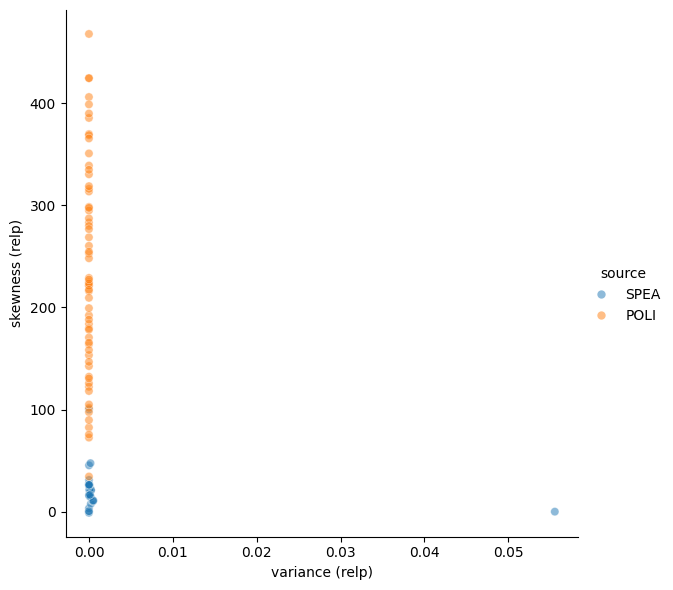

In [11]:
sns.relplot(
    x='variance (relp)',
    y='skewness (relp)',
    sizes=(40, 400),
    alpha=0.5,
    hue='source',
    height=6,
    data=table,
)